In [ ]:
%pip install geopandas --no-deps

In [ ]:
%pip install shapely

In [ ]:
%pip install fiona

In [4]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [5]:
col_dtype = {
    'Agency':"category",
    'Agency Name':"category",
    'Problem (formerly Complaint Type)':"category",
    'Problem Detail (formerly Descriptor)':"category",
    'Additional Details':"category",       
    'Location Type': "category",
    'Incident Zip':object}
col_dates = ['Created Date', 'Closed Date']

In [6]:
df = pd.read_csv('data/311_Service_Requests_from_2020_to_Present_20260326.csv', dtype=col_dtype, parse_dates=col_dates)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 44 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Unique Key                            1262 non-null   int64         
 1   Created Date                          1262 non-null   datetime64[us]
 2   Closed Date                           587 non-null    datetime64[us]
 3   Agency                                1262 non-null   category      
 4   Agency Name                           1262 non-null   category      
 5   Problem (formerly Complaint Type)     1262 non-null   category      
 6   Problem Detail (formerly Descriptor)  1262 non-null   category      
 7   Additional Details                    1262 non-null   category      
 8   Location Type                         1151 non-null   category      
 9   Incident Zip                          1262 non-null   object        
 10  Incident Ad

In [8]:
df.dropna(how='all', axis=1, inplace=True)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1262 entries, 0 to 1261
Data columns (total 35 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Unique Key                            1262 non-null   int64         
 1   Created Date                          1262 non-null   datetime64[us]
 2   Closed Date                           587 non-null    datetime64[us]
 3   Agency                                1262 non-null   category      
 4   Agency Name                           1262 non-null   category      
 5   Problem (formerly Complaint Type)     1262 non-null   category      
 6   Problem Detail (formerly Descriptor)  1262 non-null   category      
 7   Additional Details                    1262 non-null   category      
 8   Location Type                         1151 non-null   category      
 9   Incident Zip                          1262 non-null   object        
 10  Incident Ad

In [10]:
df.describe(include=['category']).T

,count,unique,top,freq
Agency,1262,1,DCWP,1262
Agency Name,1262,1,Department of Consumer and Worker Protection,1262
Problem (formerly Complaint Type),1262,1,Consumer Complaint,1262
Problem Detail (formerly Descriptor),1262,71,Tow Truck Company,110
Additional Details,1262,94,Overcharge,134
Location Type,1151,1,Business,1151


In [21]:
gdf = gpd.read_file("data/2020_Census_Tracts_20260326.geojson")

In [12]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   :id          2325 non-null   str                
 1   :version     2325 non-null   str                
 2   :created_at  2325 non-null   datetime64[ms, UTC]
 3   :updated_at  2325 non-null   datetime64[ms, UTC]
 4   ctlabel      2325 non-null   str                
 5   borocode     2325 non-null   str                
 6   boroname     2325 non-null   str                
 7   ct2020       2325 non-null   str                
 8   boroct2020   2325 non-null   str                
 9   cdeligibil   2325 non-null   str                
 10  ntaname      2325 non-null   str                
 11  nta2020      2325 non-null   str                
 12  cdta2020     2325 non-null   str                
 13  cdtaname     2325 non-null   str                
 14  geoid        232

<Axes: >

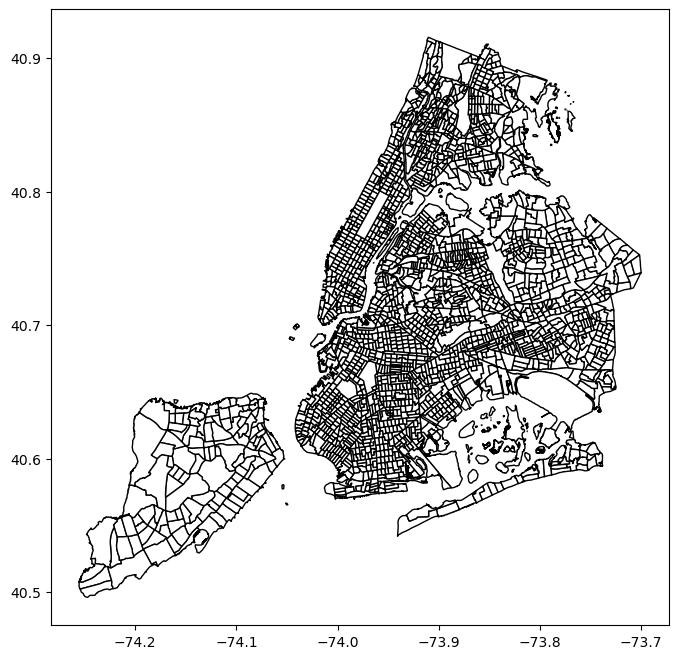

In [13]:
gdf.plot(facecolor='w', edgecolor='k', figsize=(10,8))

In [15]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   :id          2325 non-null   str                
 1   :version     2325 non-null   str                
 2   :created_at  2325 non-null   datetime64[ms, UTC]
 3   :updated_at  2325 non-null   datetime64[ms, UTC]
 4   ctlabel      2325 non-null   str                
 5   borocode     2325 non-null   str                
 6   boroname     2325 non-null   str                
 7   ct2020       2325 non-null   str                
 8   boroct2020   2325 non-null   str                
 9   cdeligibil   2325 non-null   str                
 10  ntaname      2325 non-null   str                
 11  nta2020      2325 non-null   str                
 12  cdta2020     2325 non-null   str                
 13  cdtaname     2325 non-null   str                
 14  geoid        232

In [23]:
xy311 = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude), crs="EPSG:4326")

In [27]:
xy311

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Open Data Channel Type,Park Facility Name,Park Borough,Latitude,Longitude,Location,geometry
0,68426243,2026-03-24 01:53:56,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Stoop Line Stand,Sidewalk Blocked,Business,11420,...,QUEENS,"1,035,297","185,635",ONLINE,Unspecified,QUEENS,40.676055,-73.815967,POINT (-73.815967408146 40.676054768601),POINT (-73.81597 40.67605)
1,68426242,2026-03-24 00:59:53,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Stoop Line Stand,Sidewalk Blocked,Business,10312,...,STATEN ISLAND,"933,512","143,914",ONLINE,Unspecified,STATEN ISLAND,40.561541,-74.182605,POINT (-74.182605054898 40.561541338942),POINT (-74.18261 40.56154)
2,68433700,2026-03-24 00:58:24,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,"Barber Shop, Beauty Salon, or Nail Salon",Overcharge,Business,11213,...,BROOKLYN,"1,002,605","183,158",ONLINE,Unspecified,BROOKLYN,40.669384,-73.933834,POINT (-73.933833952481 40.669384113081),POINT (-73.93383 40.66938)
3,68426296,2026-03-24 00:51:43,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Other Store (Non-Food),Credit Card Total Price Not Posted,Business,11213,...,BROOKLYN,"1,002,605","183,158",ONLINE,Unspecified,BROOKLYN,40.669384,-73.933834,POINT (-73.933833952481 40.669384113081),POINT (-73.93383 40.66938)
4,68430796,2026-03-23 23:42:36,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Other Store (Non-Food),Advertising False or Misleading,Business,10025,...,MANHATTAN,"993,589","228,758",ONLINE,Unspecified,MANHATTAN,40.794559,-73.966272,POINT (-73.966271504287 40.79455899221),POINT (-73.96627 40.79456)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1257,68173447,2026-03-01 02:28:47,2026-03-02 14:47:55,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Garage or Parking Lot,Unlicensed,Business,10460,...,BRONX,"1,015,848","246,770",PHONE,Unspecified,BRONX,40.843945,-73.885797,POINT (-73.88579671309 40.843945258696),POINT (-73.8858 40.84395)
1258,68174625,2026-03-01 02:18:00,2026-03-05 09:36:24,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Garage or Parking Lot,Unlicensed,Business,10460,...,BRONX,"1,015,848","246,770",PHONE,Unspecified,BRONX,40.843945,-73.885797,POINT (-73.88579671309 40.843945258696),POINT (-73.8858 40.84395)
1259,68167801,2026-03-01 02:12:27,NaT,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,"Bodega, Deli, or Convenience Store",Overcharge,Business,10014,...,MANHATTAN,"983,427","206,452",ONLINE,Unspecified,MANHATTAN,40.733340,-74.002970,POINT (-74.002969595066 40.733339674333),POINT (-74.00297 40.73334)
1260,68166574,2026-03-01 00:52:21,2026-03-18 10:31:10,DCWP,Department of Consumer and Worker Protection,Consumer Complaint,Other Store (Non-Food),Cash Payment Not Accepted,Business,10011,...,MANHATTAN,"984,274","205,976",PHONE,Unspecified,MANHATTAN,40.732033,-73.999913,POINT (-73.999913403543 40.732033209508),POINT (-73.99991 40.73203)


In [25]:
geo311 = gdf.sjoin(xy311, how='inner', predicate='contains', lsuffix='311')

In [26]:
geo311

,:id,:version,:created_at,:updated_at,ctlabel,borocode,boroname,ct2020,boroct2020,cdeligibil,...,BBL,Borough,X Coordinate (State Plane),Y Coordinate (State Plane),Open Data Channel Type,Park Facility Name,Park Borough,Latitude,Longitude,Location
1,row-66q9~4amv~ysyn,rv-qsim.qiq7-f57v,2026-03-09 21:04:24.381000+00:00,2026-03-09 21:04:24.381000+00:00,22.01,1,Manhattan,002201,1002201,E,...,1.003450e+09,MANHATTAN,"988,995","202,021",PHONE,Unspecified,MANHATTAN,40.721176,-73.982882,POINT (-73.982881947688 40.721176424399)
1,row-66q9~4amv~ysyn,rv-qsim.qiq7-f57v,2026-03-09 21:04:24.381000+00:00,2026-03-09 21:04:24.381000+00:00,22.01,1,Manhattan,002201,1002201,E,...,1.003330e+09,MANHATTAN,"989,746","200,579",PHONE,Unspecified,MANHATTAN,40.717218,-73.980174,POINT (-73.980173819129 40.71721804673)
3,row-x9c6-w8zb_atjj,rv-vgxh~2xjg_zcsm,2026-03-09 21:04:24.381000+00:00,2026-03-09 21:04:24.381000+00:00,28,1,Manhattan,002800,1002800,E,...,NaN,MANHATTAN,"990,071","204,546",ONLINE,Unspecified,MANHATTAN,40.728106,-73.978998,POINT (-73.978997988433 40.72810629405)
4,row-fh2m-7ntg_iphc,rv-53pa~srxj~peg7,2026-03-09 21:04:24.381000+00:00,2026-03-09 21:04:24.381000+00:00,34,1,Manhattan,003400,1003400,I,...,1.004400e+09,MANHATTAN,"989,163","205,050",ONLINE,Unspecified,MANHATTAN,40.729490,-73.982274,POINT (-73.982273659955 40.729490201893)
4,row-fh2m-7ntg_iphc,rv-53pa~srxj~peg7,2026-03-09 21:04:24.381000+00:00,2026-03-09 21:04:24.381000+00:00,34,1,Manhattan,003400,1003400,I,...,1.004400e+09,MANHATTAN,"989,033","205,420",ONLINE,Unspecified,MANHATTAN,40.730506,-73.982742,POINT (-73.982742443184 40.730505832619)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2312,row-agsx~j7k4-x9py,rv-62x2.qdyv.9kev,2026-03-09 21:04:24.381000+00:00,2026-03-09 21:04:24.381000+00:00,63.01,2,Bronx,006301,2006301,I,...,NaN,BRONX,"1,003,968","239,068",PHONE,Unspecified,BRONX,40.822840,-73.928757,POINT (-73.928756699415 40.822840013984)
2312,row-agsx~j7k4-x9py,rv-62x2.qdyv.9kev,2026-03-09 21:04:24.381000+00:00,2026-03-09 21:04:24.381000+00:00,63.01,2,Bronx,006301,2006301,I,...,2.024740e+09,BRONX,"1,004,949","240,015",ONLINE,Unspecified,BRONX,40.825437,-73.925209,POINT (-73.925209318925 40.825437014915)
2317,row-hsvi~ntbx-byin,rv-ncpf~ijp4_3cct,2026-03-09 21:04:24.381000+00:00,2026-03-09 21:04:24.381000+00:00,1188,3,Brooklyn,118800,3118800,E,...,3.041810e+09,BROOKLYN,"1,021,050","186,563",PHONE,Unspecified,BROOKLYN,40.678673,-73.867325,POINT (-73.867324958701 40.678672606526)
2322,row-4uhe_tjvm_sm5d,rv-byrc~azfq~2ahh,2026-03-09 21:04:24.381000+00:00,2026-03-09 21:04:24.381000+00:00,504.01,3,Brooklyn,050401,3050401,I,...,3.053220e+09,BROOKLYN,"991,951","176,057",PHONE,Unspecified,BROOKLYN,40.649909,-73.972248,POINT (-73.972247564365 40.649909110288)
